In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_all = pd.read_csv("csv_log/OOPT_filtered_all_Study2.csv")

# 각 id_group별로 첫 이벤트를 0초로 맞추기
if 'timestamp' in df_all.columns:
    if not pd.api.types.is_datetime64_any_dtype(df_all['timestamp']):
        df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
    df_all['time_norm'] = df_all.groupby('id_group')['timestamp'].transform(lambda x: (x - x.min()).dt.total_seconds())
    x = df_all['time_norm']
else:
    x = df_all.index

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all['id_group'].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}
y = df_all['id_group'].map(id_group_to_y)

# 이벤트 그룹별 색상 팔레트
from matplotlib.colors import to_rgba
import numpy as np

# ---- 이벤트 그룹별 색상 팔레트 ----
base_colors = {
    'class': plt.cm.Blues,     # 파랑 계열
    'instance': plt.cm.Reds,   # 빨강 계열
    'object': plt.cm.Greens,   # 초록 계열
    'other': plt.cm.Purples,   # 보라 계열 (orange 대신 확실히 구분)
    'api': plt.cm.Greys,             # 단색 검정
}

event_types = sorted(df_all['event'].unique())
event_to_group = []
for ev in event_types:
    if ev == 'api.generate_image.succeeded':
        event_to_group.append('api')
    elif ev == 'layout_board.new_box_positioned':
        event_to_group.append('layout')
    elif ev.startswith('class'):
        event_to_group.append('class')
    elif ev.startswith('instance'):
        event_to_group.append('instance')
    elif ev.startswith('object_node'):
        event_to_group.append('object')
    else:
        event_to_group.append('other')

# ---- 그룹별 색상 매핑 (이벤트마다 다른 색) ----
group_counts = {}
for g in event_to_group:
    group_counts[g] = group_counts.get(g, 0) + 1

event_to_color = {}
for group in set(event_to_group):
    cmap = base_colors[group]
    n = group_counts[group]
    # colormap에서 균등 분할 (0.3~0.9 구간)
    colors = [cmap(x) for x in np.linspace(0.9, 0.3, n)]
    i = 0
    for ev, g in zip(event_types, event_to_group):
        if g == group:
            event_to_color[ev] = colors[i]
            i += 1

# 1) 인스턴스 하위 타입 스타일 매핑
marker_map = {
    'class.created': 'D',
    'class.updated': 'D',
    'class.instances_reset': 'D',
    'instance.created_from_class': 'D',   # ◆ 다이아몬드
    'instance.created_from_text': 'o',    # ■ 네모
    'instance.created_from_detection': '^', # ▲ 삼각형
    'instance.updated': 's',              # ● 원
}
alpha_map = {
    'instance.created_from_class': 0.95,
    'instance.created_from_text': 0.95,
    'instance.created_from_detection': 0.95,
    'instance.updated': 0.65,             # 업데이트는 연하게
}
edge_map = {
    'instance.created_from_class': 'none',
    'instance.created_from_text': 'none',
    'instance.created_from_detection': 'none',
    'instance.updated': 'none',
}

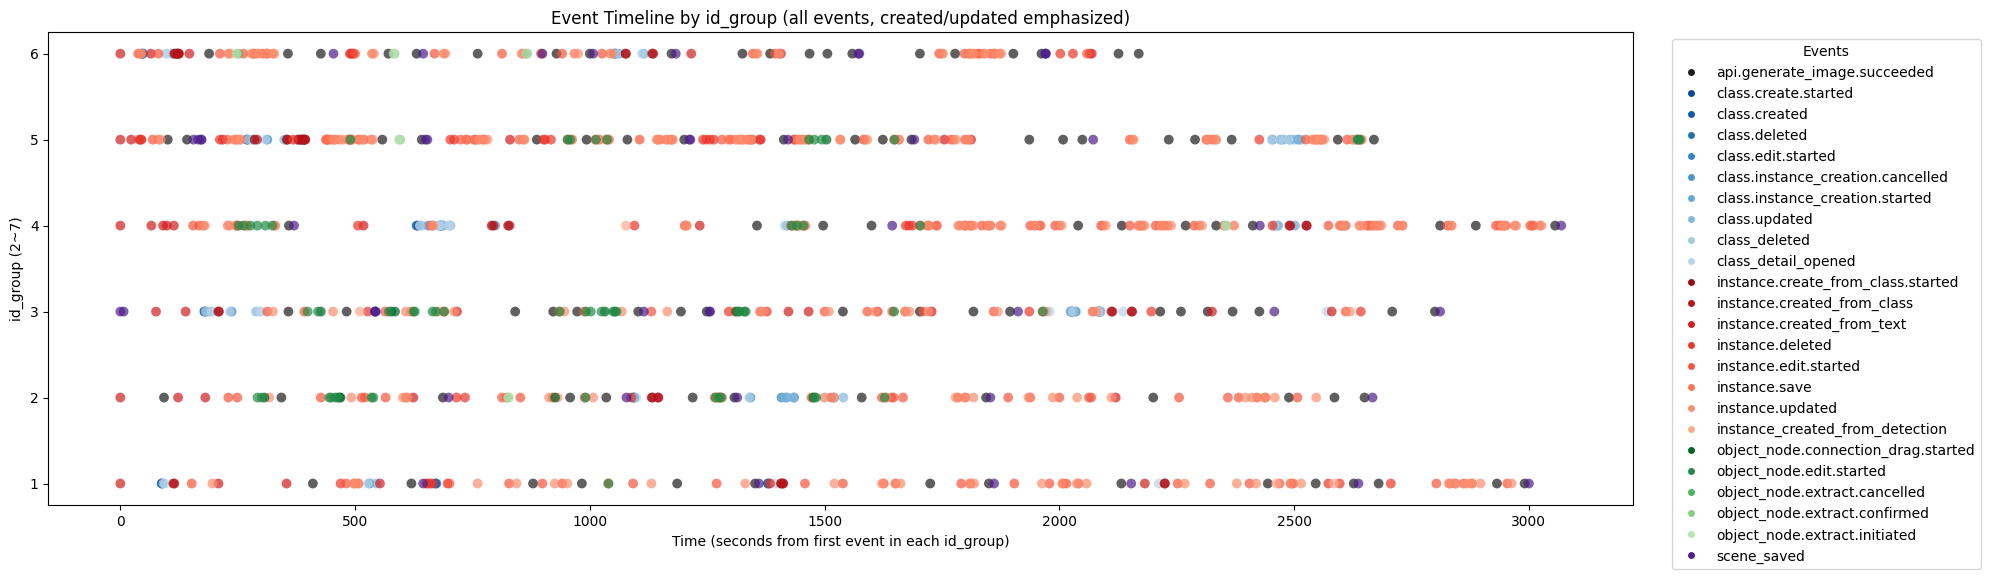

In [14]:
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(20, max(6, len(id_groups_sorted)*0.7)))
rng = np.random.default_rng(42)

legend_elems = []  # legend 수동 구성

for ev in event_types:
    mask = df_all['event'] == ev
    group = [g for e,g in zip(event_types, event_to_group) if e == ev][0]
    y_jitter = y[mask] #.to_numpy(dtype=float) + rng.uniform(-0.05, 0.05, size=mask.sum())

    # 기본 스타일
    scatter_args = dict(
        x=x[mask],
        y=y_jitter,
        color=event_to_color[ev],
        marker='o',
        s=50,
        alpha=0.7,
        edgecolors='none',
        linewidths=0,
    )

    # # 강조 이벤트
    # if ev in ['class.created', 'class.updated',
    #           'instance.created_from_class', 'instance.updated']:
    #     scatter_args.update(dict(
    #         s=50,
    #         edgecolors='k',
    #         linewidths=0.8,
    #         # # # # zorder=5
    #     ))

    plt.scatter(**scatter_args)

    # legend entry 생성
    legend_elems.append(
        Line2D([0],[0],
               marker='o',
               color='w',
               markerfacecolor=event_to_color[ev],
            #    markeredgecolor=('k' if ev in ['class.created','class.updated',
            #                                   'instance.created_from_class','instance.updated'] else 'none'),
               markersize=(6 if ev in ['class.created','class.updated',
                                       'instance.created_from_class','instance.updated'] else 6),
               label=ev)
    )

plt.xlabel('Time (seconds from first event in each id_group)')
plt.ylabel('id_group (2~7)')
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title('Event Timeline by id_group (all events, created/updated emphasized)')

plt.legend(handles=legend_elems, bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
plt.tight_layout()
plt.show()


# Change Labels
class_instances_reset -> class.instances_reset
instance_created_from_detection -> instance.created_from_detection

# Load DELETED

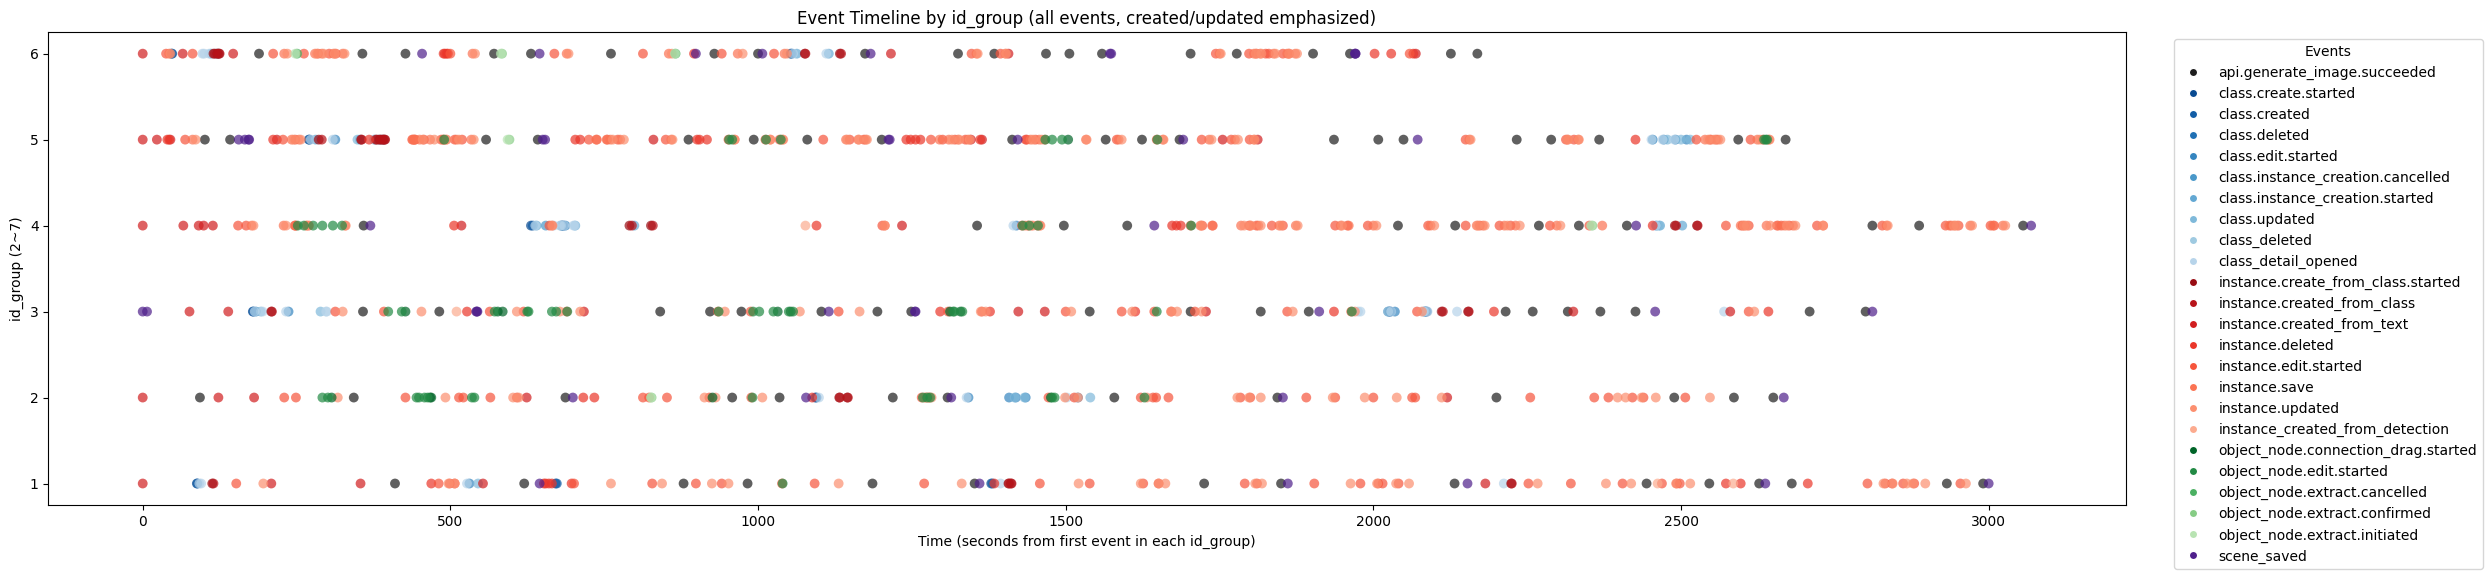

In [15]:
df_all = pd.read_csv("csv_log/OOPT_filtered_all_Study2.csv")
event_types = sorted(df_all['event'].unique())

# 각 id_group별로 첫 이벤트를 0초로 맞추기
if 'timestamp' in df_all.columns:
    if not pd.api.types.is_datetime64_any_dtype(df_all['timestamp']):
        df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
    df_all['time_norm'] = df_all.groupby('id_group')['timestamp'].transform(lambda x: (x - x.min()).dt.total_seconds())
    x = df_all['time_norm']
else:
    x = df_all.index

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all['id_group'].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}
y = df_all['id_group'].map(id_group_to_y)

from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(25, max(6, len(id_groups_sorted)*0.7)))
rng = np.random.default_rng(42)

legend_elems = []  # legend 수동 구성

for ev in event_types:
    mask = df_all['event'] == ev
    
    
    group = [g for e,g in zip(event_types, event_to_group) if e == ev][0]
    y_jitter = y[mask] #.to_numpy(dtype=float) + rng.uniform(-0.05, 0.05, size=mask.sum())

    # 기본 스타일
    scatter_args = dict(
        x=x[mask],
        y=y_jitter,
        color=event_to_color[ev],
        marker='o',
        s=50,
        alpha=0.7,
        edgecolors='none',
        linewidths=0,
    )

    # # 강조 이벤트
    # if ev in ['class.created', 'class.updated',
    #           'instance.created_from_class', 'instance.updated']:
    #     scatter_args.update(dict(
    #         s=50,
    #         edgecolors='k',
    #         linewidths=0.8,
    #         # # # # zorder=5
    #     ))

    plt.scatter(**scatter_args)

    # legend entry 생성
    legend_elems.append(
        Line2D([0],[0],
               marker='o',
               color='w',
               markerfacecolor=event_to_color[ev],
            #    markeredgecolor=('k' if ev in ['class.created','class.updated',
            #                                   'instance.created_from_class','instance.updated'] else 'none'),
               markersize=(6 if ev in ['class.created','class.updated',
                                       'instance.created_from_class','instance.updated'] else 6),
               label=ev)
    )

plt.xlabel('Time (seconds from first event in each id_group)')
plt.ylabel('id_group (2~7)')
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title('Event Timeline by id_group (all events, created/updated emphasized)')

plt.legend(handles=legend_elems, bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
plt.tight_layout()
plt.show()


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_92353/3740014647.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_init = df_all.groupby('id_group', group_keys=False).apply(filter_before_first_gen)


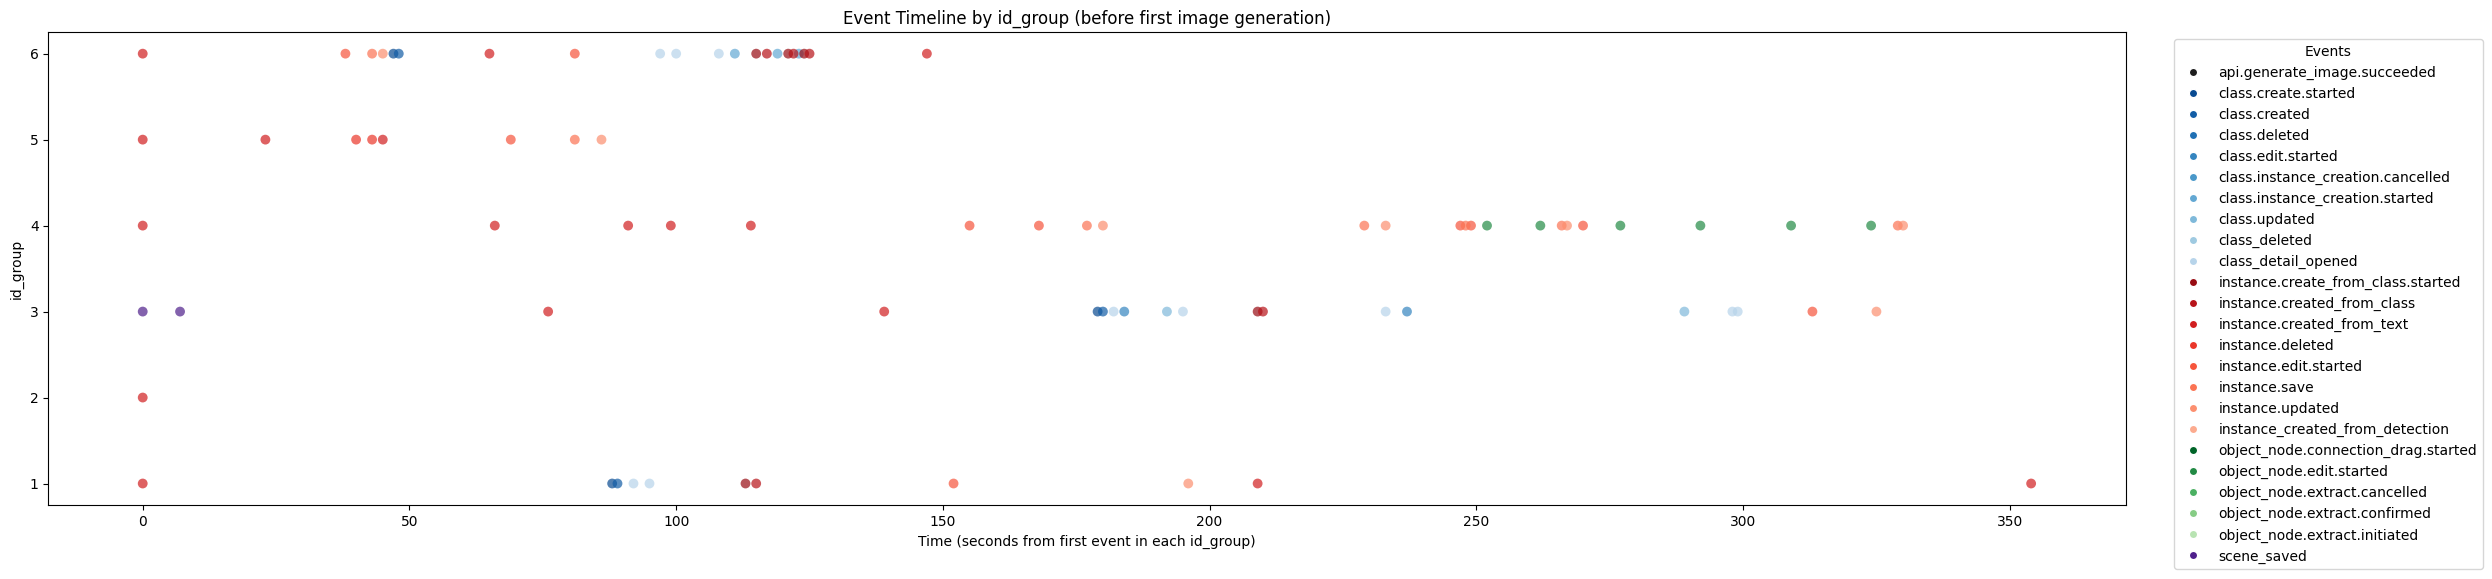

In [16]:
# 1. 각 id_group별 첫 generation 시점 찾기
first_gen_time = (
    df_all[df_all['event'] == 'api.generate_image.succeeded']
    .groupby('id_group')['time_norm'].min()
)

# 2. 첫 generation 이전 이벤트만 남기기
def filter_before_first_gen(g):
    cutoff = first_gen_time.get(g.name, np.inf)  # generation 없으면 전체 유지
    return g[g['time_norm'] < cutoff]

df_init = df_all.groupby('id_group', group_keys=False).apply(filter_before_first_gen)
df_init = df_init.drop_duplicates()

# 이후 df_all 대신 df_init 사용
event_types = sorted(df_init['event'].unique())
x = df_init['time_norm']
y = df_init['id_group'].map(id_group_to_y)

plt.figure(figsize=(25, max(6, len(id_groups_sorted)*0.7)))
for ev in event_types:
    mask = df_init['event'] == ev
    scatter_args = dict(
        x=x[mask], y=y[mask],
        color=event_to_color[ev],
        marker='o', s=50, alpha=0.7,
        edgecolors='none', linewidths=0,
    )
    # if ev in ['class.created','class.updated',
    #           'instance.created_from_class','instance.updated']:
    #     scatter_args.update(dict(edgecolors='k', linewidths=0.8))
    plt.scatter(**scatter_args)

plt.xlabel('Time (seconds from first event in each id_group)')
plt.ylabel('id_group')
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title('Event Timeline by id_group (before first image generation)')
plt.legend(handles=legend_elems, bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
plt.tight_layout()
plt.show()


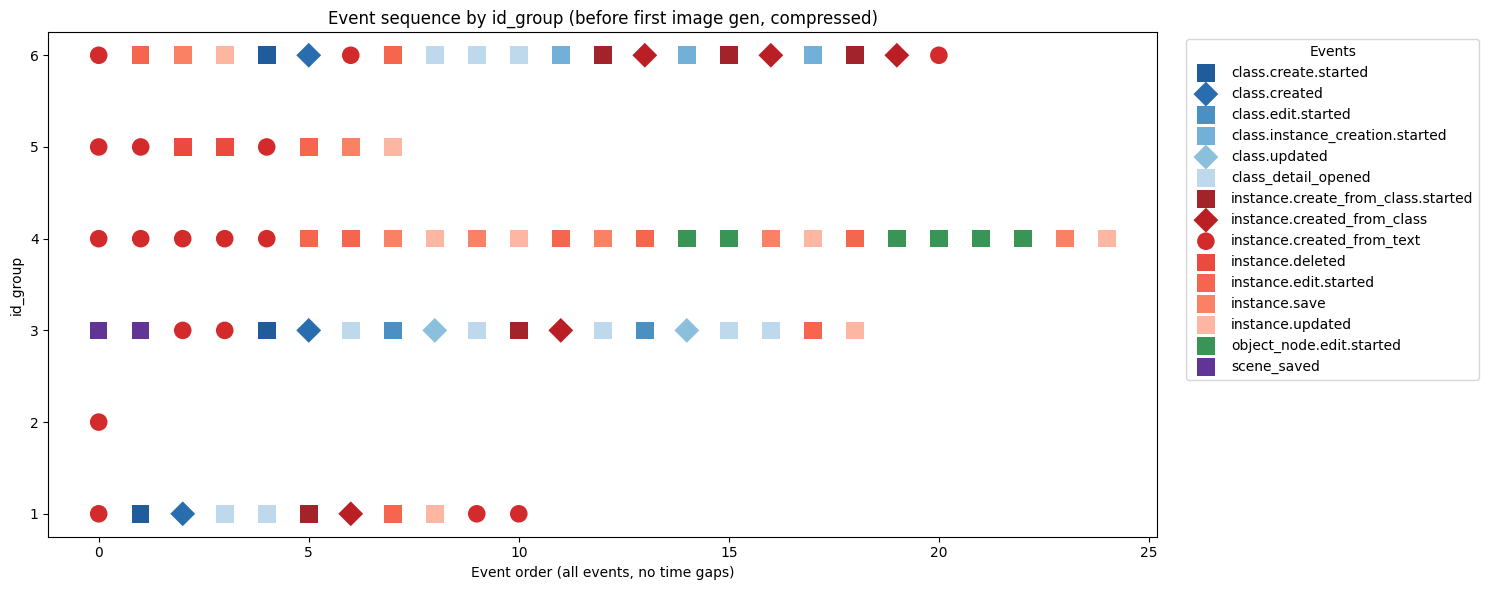

In [17]:
# 1) 시간순 정렬
df_sorted = df_init.sort_values(['id_group','time_norm']).copy()

# 2) 참가자별 순서 인덱스 부여 (반복 이벤트 포함)
df_sorted['seq_idx'] = df_sorted.groupby('id_group').cumcount()

# 3) 플롯
event_types = sorted(df_sorted['event'].unique())

plt.figure(figsize=(15, max(6, len(id_groups_sorted)*0.7)))

for ev in event_types:
    mask = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')  # 기본은 네모
    alpha  = alpha_map.get(ev, 0.9)
    edge   = edge_map.get(ev, 'none')
    plt.scatter(
        df_sorted.loc[mask, 'seq_idx'],                       # X = 이벤트 순서 (0,1,2,…)
        df_sorted.loc[mask, 'id_group'].map(id_group_to_y),   # Y = 참가자
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
        edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None
    )

plt.xlabel('Event order (all events, no time gaps)')
plt.ylabel('id_group')
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title('Event sequence by id_group (before first image gen, compressed)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
plt.tight_layout()
plt.show()


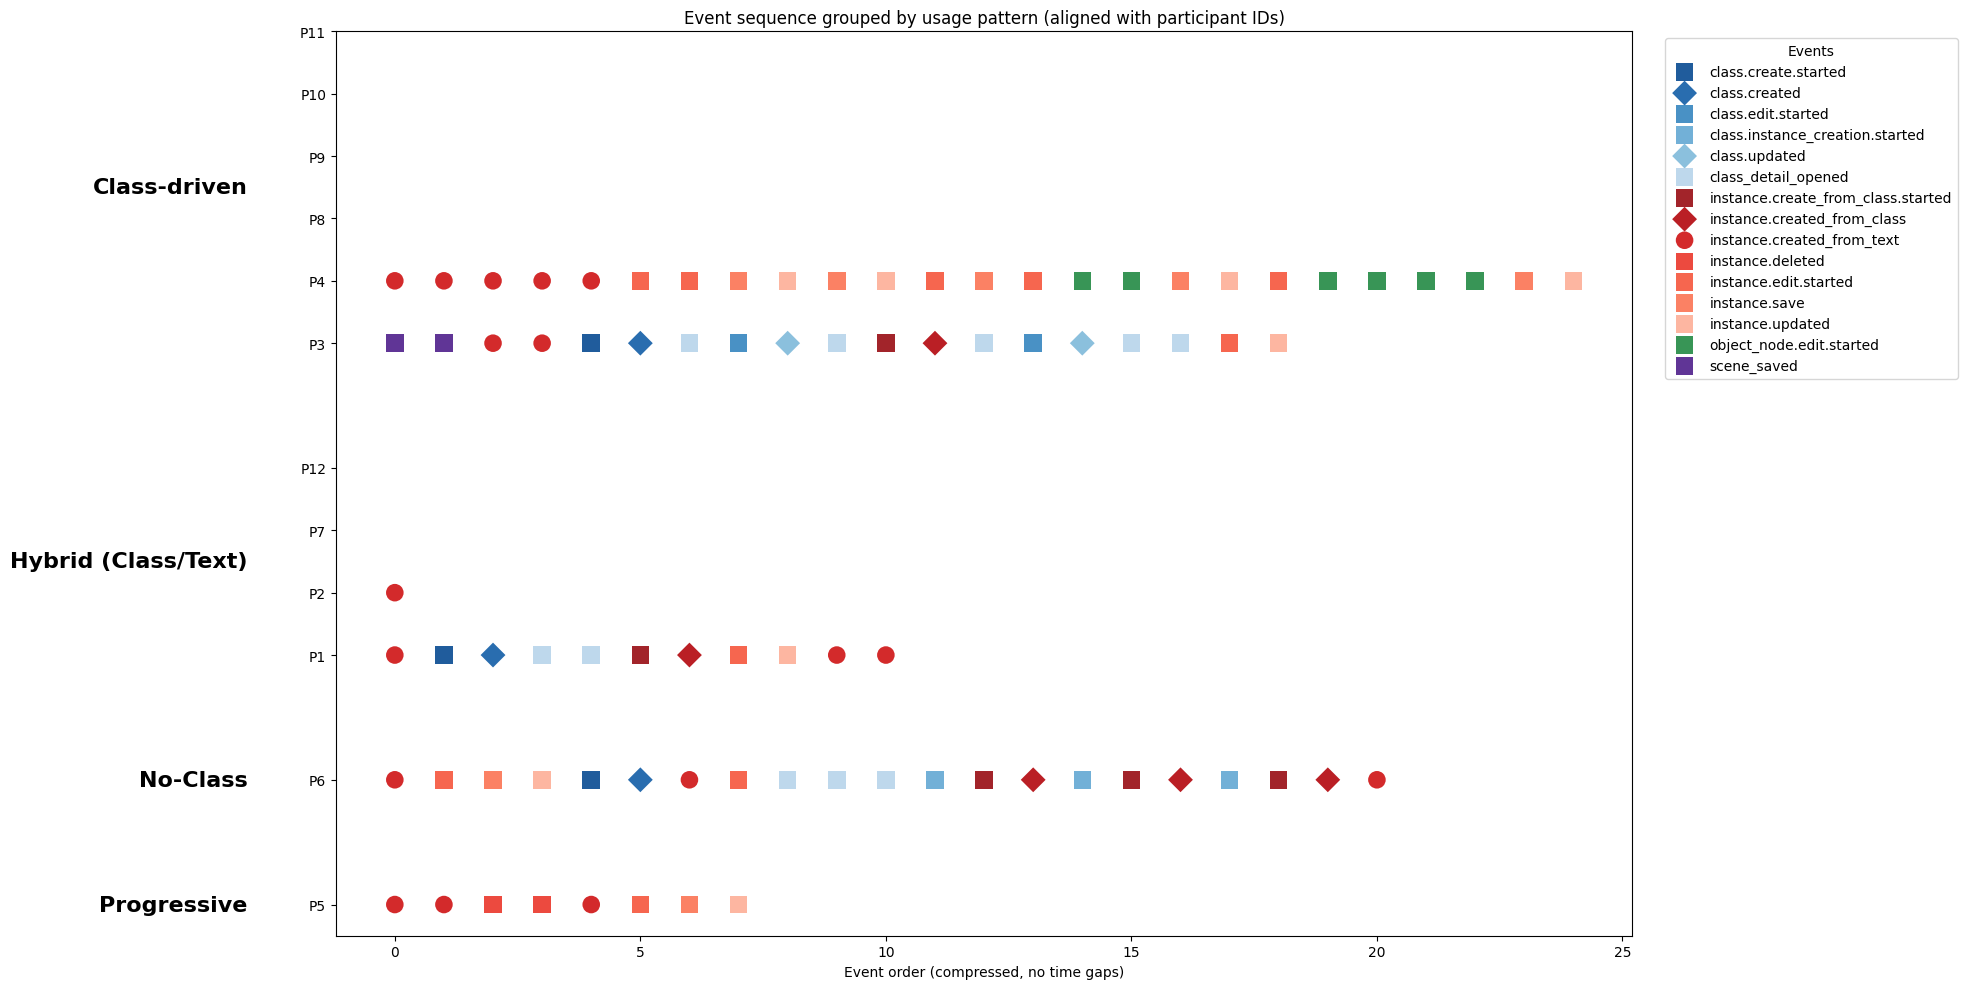

In [18]:
import matplotlib.pyplot as plt

# ---- 1) 그룹 매핑 ----
group_map = {
    3: "Class-driven", 4: "Class-driven", 8: "Class-driven", 9: "Class-driven", 10: "Class-driven", 11: "Class-driven",
    1: "Hybrid (Class/Text)", 2: "Hybrid (Class/Text)", 7: "Hybrid (Class/Text)", 12: "Hybrid (Class/Text)",
    5: "Progressive", 6: "No-Class"
}
df_sorted["group_label"] = df_sorted["id_group"].map(group_map)

# ---- 참가자 순서 (그룹 포함) ----
group_order = ["Class-driven", "Hybrid (Class/Text)", "No-Class", "Progressive"]
group_order.reverse()

yticks = []
yticklabels = []
y_val = 0
group_centers = {}

for g in group_order:
    members = sorted([pid for pid, grp in group_map.items() if grp == g])
    for pid in members:
        yticks.append(y_val)
        yticklabels.append(f"P{pid}")  # 참가자만
        y_val += 1
    group_centers[g] = (yticks[-len(members)] + yticks[-1]) / 2  # 그룹 중앙
    y_val += 1  # 그룹 간격 띄우기

# ---- 이벤트 좌표 ----
id_to_y = {int(label[1:]): yticks[i] for i, label in enumerate(yticklabels)}
df_sorted["y_axis"] = df_sorted["id_group"].map(id_to_y)

# ---- Plot ----
plt.figure(figsize=(20, 10))
event_types = sorted(df_sorted['event'].unique())

for ev in event_types:
    mask = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')  # 기본은 네모
    alpha  = alpha_map.get(ev, 0.9)
    edge   = edge_map.get(ev, 'none')

    plt.scatter(
        df_sorted.loc[mask, 'seq_idx'],
        df_sorted.loc[mask, 'y_axis'],            # 네가 쓰는 y값 변수명에 맞춰
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
        edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None
    )
# 참가자 라벨
plt.yticks(yticks, yticklabels)

# 그룹 라벨 (왼쪽에 크게)
for g, center in group_centers.items():
    plt.text(-3, center, g, va="center", ha="right", fontsize=16, fontweight="bold")

plt.xlabel("Event order (compressed, no time gaps)")
# plt.ylabel("Participants")
plt.title("Event sequence grouped by usage pattern (aligned with participant IDs)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Events")
plt.tight_layout()
plt.show()


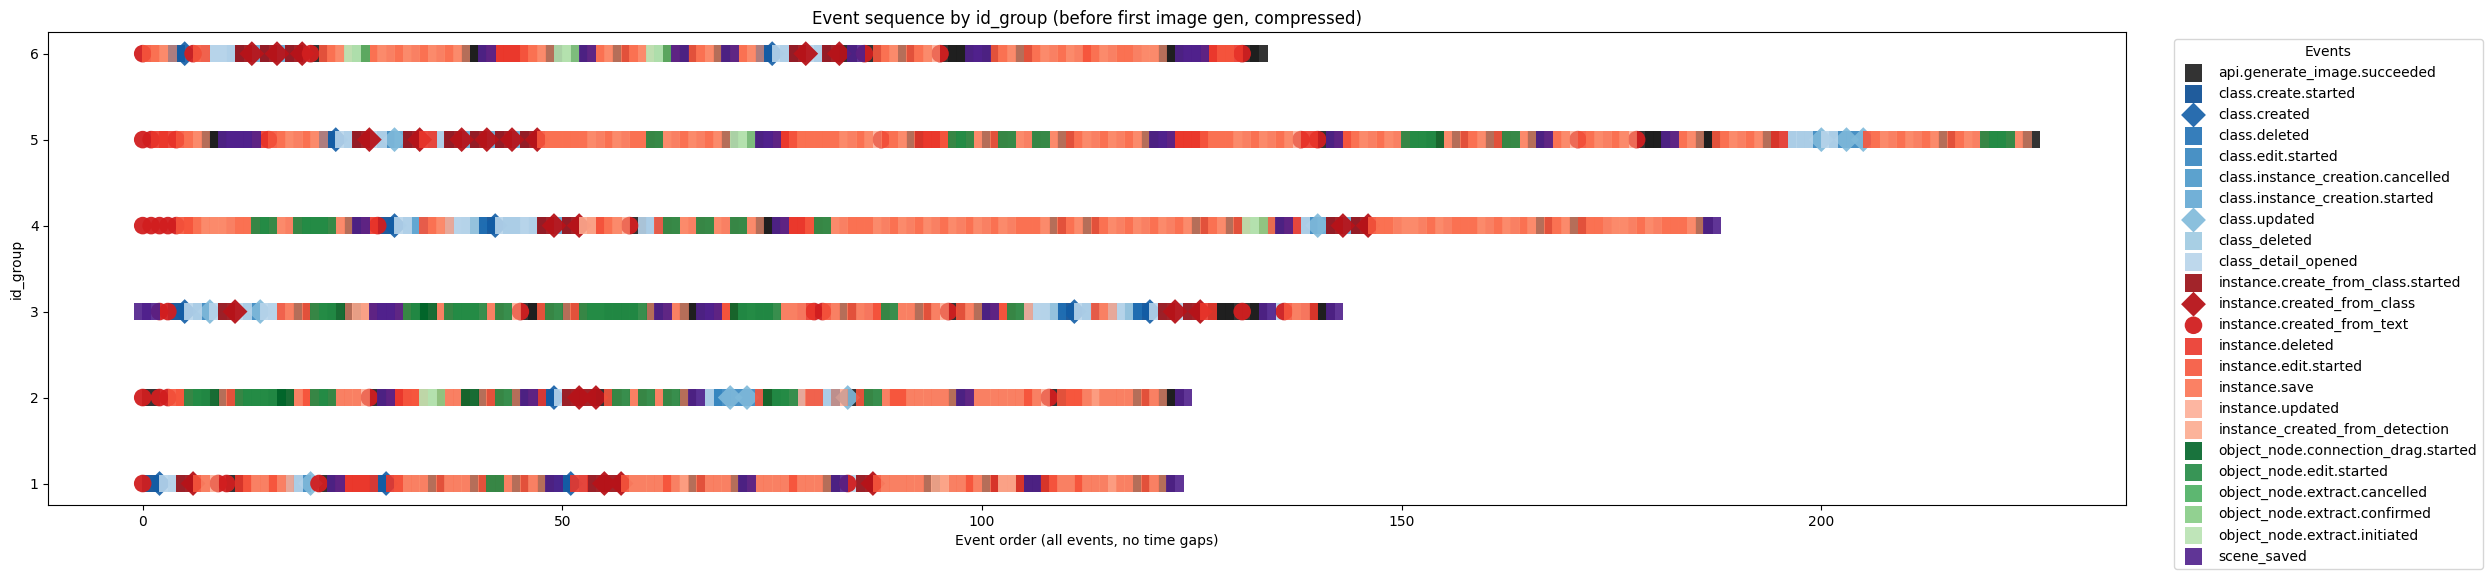

In [19]:
# 1) 시간순 정렬
df_all = df_all.drop_duplicates()
df_sorted = df_all.sort_values(['id_group','time_norm']).copy()

# 2) 참가자별 순서 인덱스 부여 (반복 이벤트 포함)
df_sorted['seq_idx'] = df_sorted.groupby('id_group').cumcount()

# 3) 플롯
event_types = sorted(df_sorted['event'].unique())

plt.figure(figsize=(25, max(6, len(id_groups_sorted)*0.7)))

for ev in event_types:
    mask = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')  # 기본은 네모
    alpha  = alpha_map.get(ev, 0.9)
    edge   = edge_map.get(ev, 'none')
    plt.scatter(
        df_sorted.loc[mask, 'seq_idx'],                       # X = 이벤트 순서 (0,1,2,…)
        df_sorted.loc[mask, 'id_group'].map(id_group_to_y),   # Y = 참가자
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
        edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None
    )

plt.xlabel('Event order (all events, no time gaps)')
plt.ylabel('id_group')
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title('Event sequence by id_group (before first image gen, compressed)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
plt.tight_layout()
plt.show()


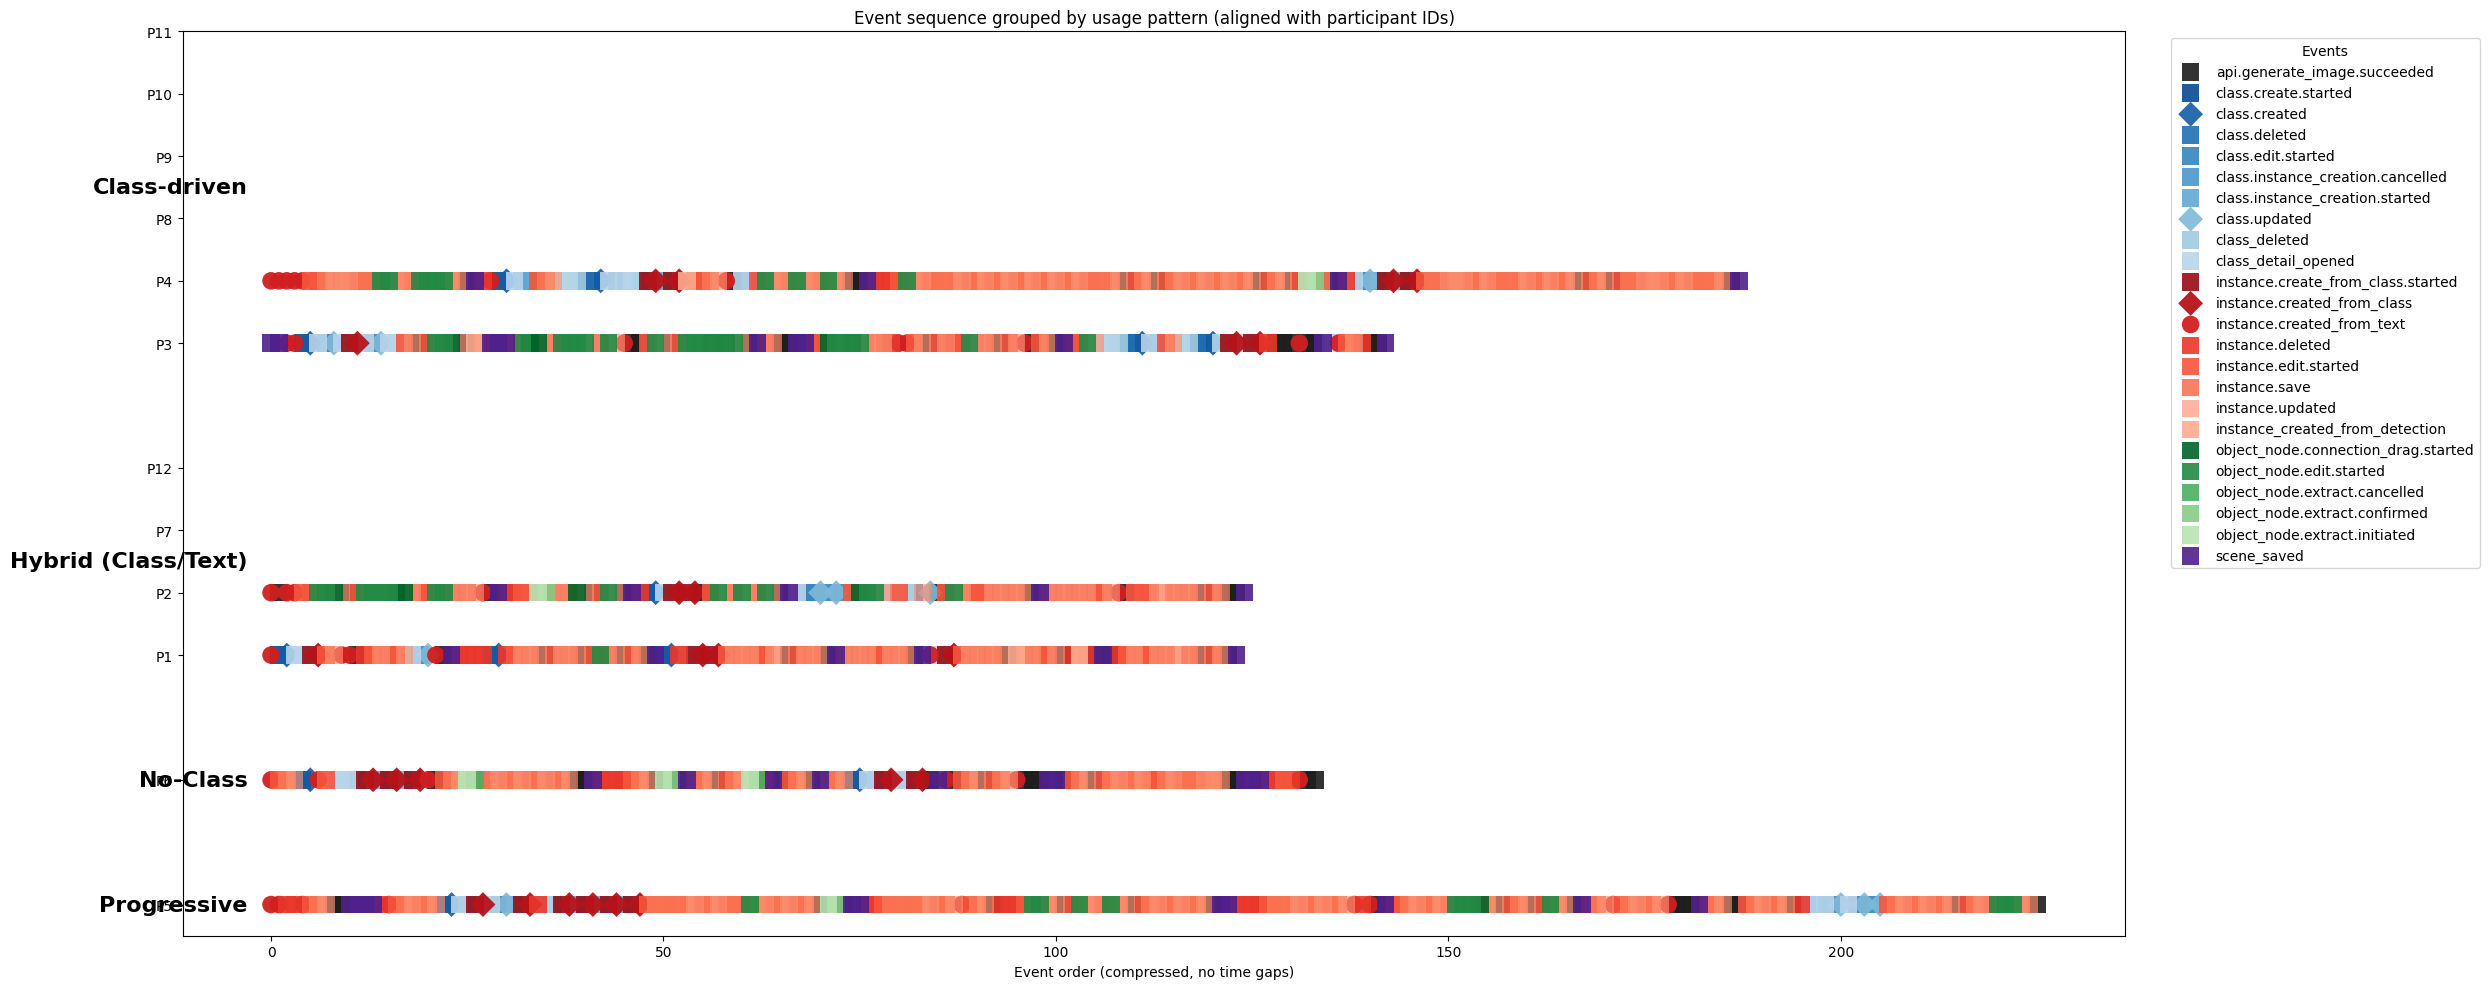

In [20]:
import matplotlib.pyplot as plt


# ---- 1) 그룹 매핑 ----
group_map = {
    3: "Class-driven", 4: "Class-driven", 8: "Class-driven", 9: "Class-driven", 10: "Class-driven", 11: "Class-driven",
    1: "Hybrid (Class/Text)", 2: "Hybrid (Class/Text)", 7: "Hybrid (Class/Text)", 12: "Hybrid (Class/Text)",
    5: "Progressive", 6: "No-Class"
}
df_sorted["group_label"] = df_sorted["id_group"].map(group_map)

# ---- 참가자 순서 (그룹 포함) ----
group_order = ["Class-driven", "Hybrid (Class/Text)", "No-Class", "Progressive"]
group_order.reverse()

yticks = []
yticklabels = []
y_val = 0
group_centers = {}

for g in group_order:
    members = sorted([pid for pid, grp in group_map.items() if grp == g])
    for pid in members:
        yticks.append(y_val)
        yticklabels.append(f"P{pid}")  # 참가자만
        y_val += 1
    group_centers[g] = (yticks[-len(members)] + yticks[-1]) / 2  # 그룹 중앙
    y_val += 1  # 그룹 간격 띄우기

# ---- 이벤트 좌표 ----
id_to_y = {int(label[1:]): yticks[i] for i, label in enumerate(yticklabels)}
df_sorted["y_axis"] = df_sorted["id_group"].map(id_to_y)

# ---- Plot ----
plt.figure(figsize=(25, 10))
event_types = sorted(df_sorted['event'].unique())


# 2) scatter 그릴 때 분기
for ev in event_types:
    mask = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')  # 기본은 네모
    alpha  = alpha_map.get(ev, 0.9)
    edge   = edge_map.get(ev, 'none')

    plt.scatter(
        df_sorted.loc[mask, 'seq_idx'],
        df_sorted.loc[mask, 'y_axis'],            # 네가 쓰는 y값 변수명에 맞춰
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
        edgecolors=edge, linewidths=0.8 if edge!='none' else 0,
        label=ev if ev not in plt.gca().get_legend_handles_labels()[1] else None
    )


# 참가자 라벨
plt.yticks(yticks, yticklabels)

# 그룹 라벨 (왼쪽에 크게)
for g, center in group_centers.items():
    plt.text(-3, center, g, va="center", ha="right", fontsize=16, fontweight="bold")

plt.xlabel("Event order (compressed, no time gaps)")
# plt.ylabel("Participants")
plt.title("Event sequence grouped by usage pattern (aligned with participant IDs)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Events")
plt.tight_layout()
plt.show()


In [21]:
import numpy as np
import pandas as pd

# (1) object_node.extract.confirmed 카운트
obj_counts = (
    df_all[df_all['event']=='object_node.extract.confirmed']
    .groupby('id_group').size()
    .reindex(sorted(df_all['id_group'].unique()), fill_value=0)
    .rename('obj_cnt')
)

# (2) 기존 상위 그룹 레이블(네가 쓰던 것) 예시
group_map = {
    3:'Class-driven',4:'Class-driven',8:'Class-driven',9:'Class-driven',10:'Class-driven',11:'Class-driven',
    1:'Hybrid',2:'Hybrid',7:'Hybrid',12:'Hybrid',
    5:'Progressive',6:'No-Class'
}
group_ser = pd.Series(group_map, name='group')

# (3) 분위수 기준으로 Heavy/Light/None 부여 (그룹별 독립 기준)
df_g = pd.concat([obj_counts, group_ser], axis=1)
sub_labels = {}
for g, sub in df_g.groupby('group'):
    # None
    none_ids = sub.index[sub['obj_cnt']==0]
    for pid in none_ids:
        sub_labels[pid] = f"{g}-Object-None"
    # Heavy/Light (0이 아닌 대상만 분위수로 분리)
    pos = sub[sub['obj_cnt']>0]['obj_cnt']
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            sub_labels[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

subtype_ser = pd.Series(sub_labels, name='subtype')  # id_group -> subtype
# 필요하면 테이블로 확인
summary = df_g.join(subtype_ser)
print(summary.sort_index())


    obj_cnt         group                    subtype
1       0.0        Hybrid         Hybrid-Object-None
2       1.0        Hybrid        Hybrid-Object-Heavy
3       0.0  Class-driven   Class-driven-Object-None
4       1.0  Class-driven  Class-driven-Object-Heavy
5       1.0   Progressive   Progressive-Object-Heavy
6       1.0      No-Class      No-Class-Object-Heavy
7       NaN        Hybrid                        NaN
8       NaN  Class-driven                        NaN
9       NaN  Class-driven                        NaN
10      NaN  Class-driven                        NaN
11      NaN  Class-driven                        NaN
12      NaN        Hybrid                        NaN


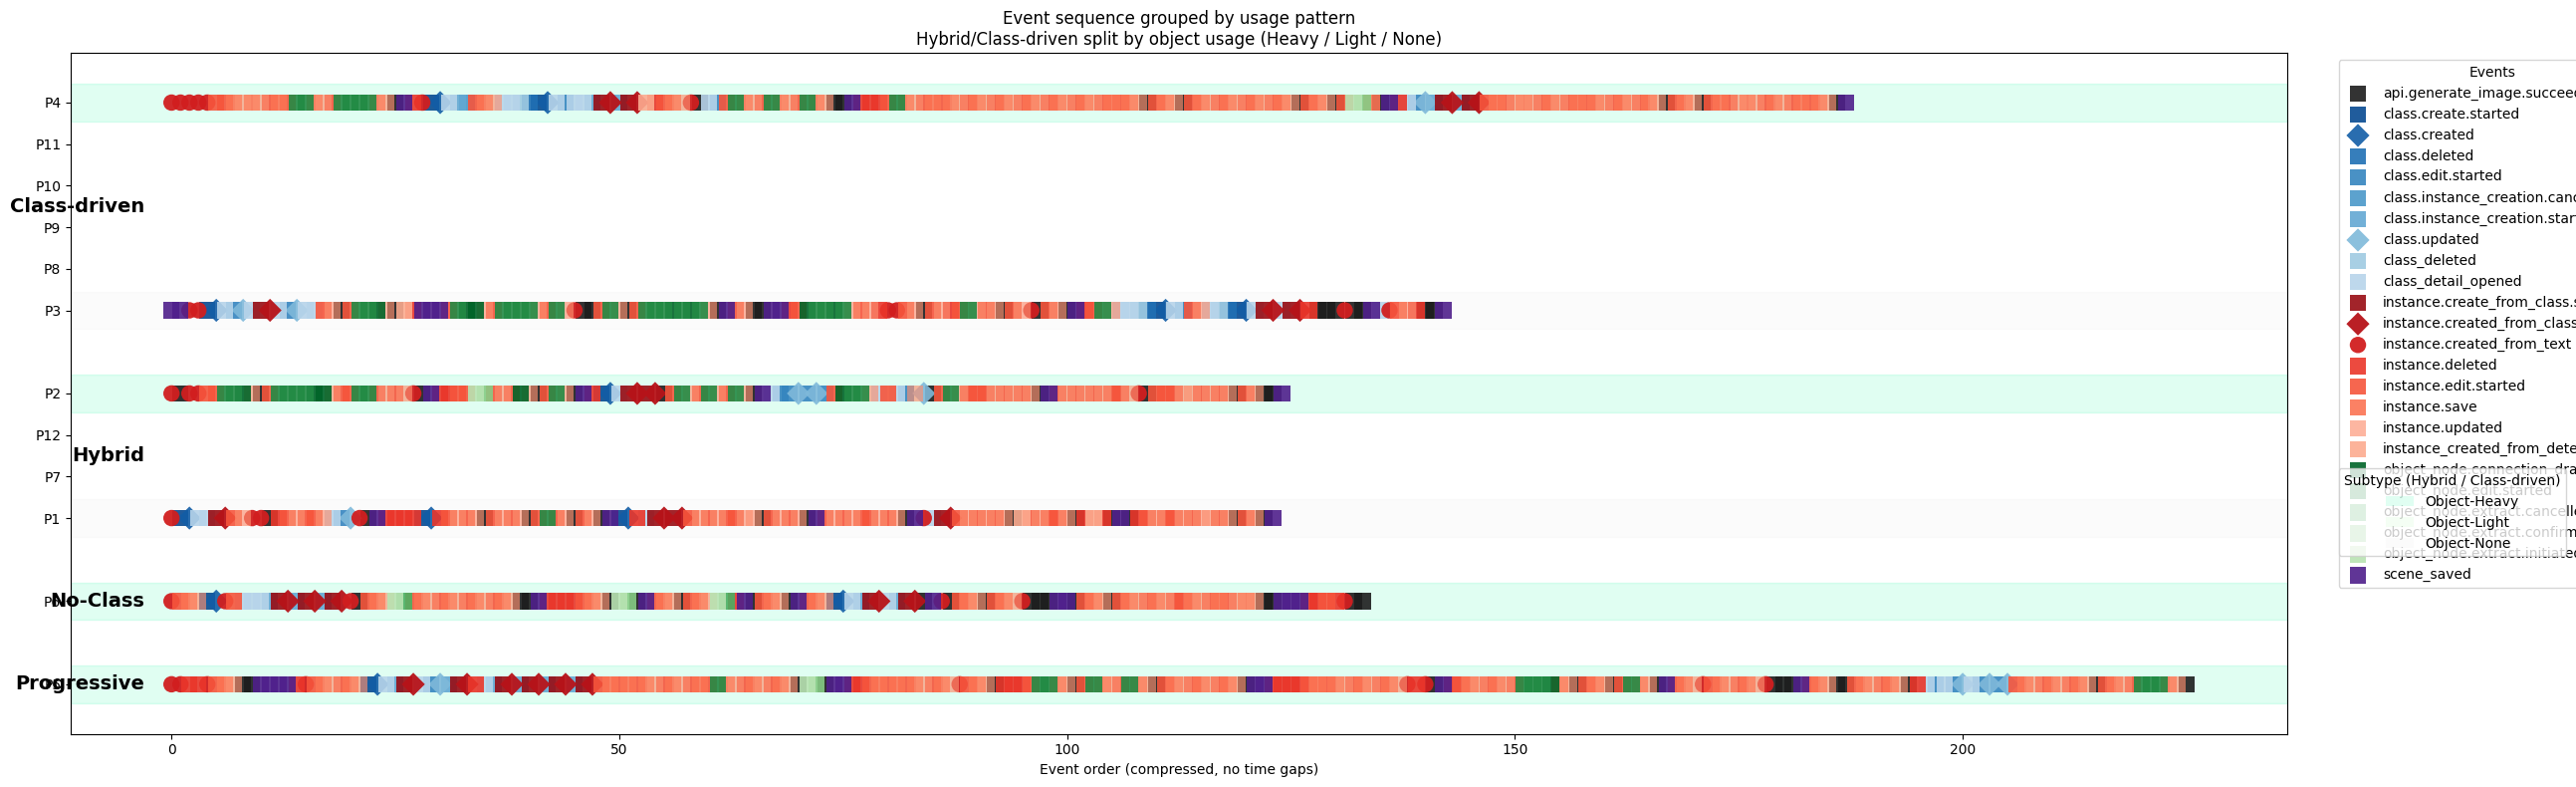

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ────────────────────────────────────────────────────────────────────────────
# 0) 준비: 시간 정렬 + 순서 인덱스(간격 제거)
# ────────────────────────────────────────────────────────────────────────────
df = df_all.copy()

if 'timestamp' in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(['id_group','timestamp']).copy()
else:
    # timestamp가 없으면 원래 순서대로 id_group 내에서 정렬
    df = df.sort_values(['id_group']).copy()

df['seq_idx'] = df.groupby('id_group').cumcount()

# ────────────────────────────────────────────────────────────────────────────
# 1) 상위 그룹(전략) 매핑  ← 네가 쓰던 것 그대로
# ────────────────────────────────────────────────────────────────────────────
group_map = {
    3:'Class-driven',4:'Class-driven',8:'Class-driven',9:'Class-driven',10:'Class-driven',11:'Class-driven',
    1:'Hybrid',2:'Hybrid',7:'Hybrid',12:'Hybrid',
    5:'Progressive',6:'No-Class'
}
df['group'] = df['id_group'].map(group_map)

# ────────────────────────────────────────────────────────────────────────────
# 2) object 사용량으로 Hybrid/Class-driven을 서브타입 분기 (Heavy / Light / None)
#    - 같은 상위그룹 내에서 분위수 기준으로 나눔
# ────────────────────────────────────────────────────────────────────────────
obj_cnt = (df[df['event']=='object_node.extract.confirmed']
           .groupby('id_group').size())
obj_cnt = obj_cnt.reindex(sorted(df['id_group'].unique()), fill_value=0)

tmp = pd.DataFrame({
    'group': pd.Series(group_map),
    'obj_cnt': obj_cnt
}).dropna(subset=['group'])

subtype = {}
for g, sub in tmp.groupby('group'):
    # No-Class는 서브타입 구분 안 함
    if g not in ['Hybrid', 'Class-driven', 'No-Class', 'Progressive']:
        for pid in sub.index:
            subtype[pid] = f"{g}"
        continue

    # None
    none_ids = sub.index[sub['obj_cnt']==0]
    for pid in none_ids:
        subtype[pid] = f"{g}-Object-None"

    # Heavy/Light (0 초과만)
    pos = sub[sub['obj_cnt']>0]['obj_cnt']
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            subtype[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

# 맵핑 붙이기
df['subtype'] = df['id_group'].map(subtype).fillna(df['group'])

# 기본값 보정 함수
def style_for(ev):
    marker = marker_map.get(ev, 's')
    alpha  = alpha_map.get(ev, 0.9)
    edge   = edge_map.get(ev, 'k' if ev.startswith('instance.created_') else 'none')
    lw     = 0.8 if edge!='none' else 0
    return marker, alpha, edge, lw

# ────────────────────────────────────────────────────────────────────────────
# 4) y축 구성 (그룹 내부 정렬: Heavy → Light → None, 동률은 obj_cnt 내림차순 → id)
# ────────────────────────────────────────────────────────────────────────────
group_order = ['Class-driven', 'Hybrid', 'No-Class', 'Progressive']  # 원하는 순서
group_order.reverse()

# 서브타입 우선순위
prio = {'Object-Heavy': 2, 'Object-Light': 1, 'Object-None': 0}

def subtype_bucket(pid):
    """서브타입 라벨에서 버킷만 추출 (No-Class는 None 취급)"""
    st = subtype.get(pid, group_map.get(pid, ''))
    if 'Object-Heavy' in st: return 'Object-Heavy'
    if 'Object-Light' in st: return 'Object-Light'
    if 'Object-None' in st: return 'Object-None'
    return 'Object-None'  # No-Class 포함

def sort_key(pid):
    bucket = subtype_bucket(pid)
    return (prio.get(bucket, 3), -int(obj_cnt.get(pid, 0)), int(pid))

rows = []
y = 0
group_centers = {}
yticks, ylabels = [], []

for g in group_order:
    # 이 그룹의 멤버 수집
    members = [pid for pid, gg in group_map.items() if gg == g]
    if not members:
        continue

    # 버킷 우선 정렬
    members_sorted = sorted(members, key=sort_key)

    start_y = y
    for pid in members_sorted:
        rows.append((pid, y))
        yticks.append(y)
        short = subtype.get(pid, g).replace('Class-driven-','').replace('Hybrid-','')
        ylabels.append(f"P{pid}")
        y += 1
    group_centers[g] = (start_y + y - 1) / 2
    y += 1  # 그룹 간 빈 줄

# id→y 매핑 업데이트 및 y축 값 부여
id_to_y = dict(rows)
df['y_axis'] = df['id_group'].map(id_to_y)

# ────────────────────────────────────────────────────────────────────────────
# 5) 플롯
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 8))

# (a) 서브타입 하이라이트 밴드 (Hybrid/Class-driven만)
for pid, yy in id_to_y.items():
    st = subtype.get(pid, group_map.get(pid,''))
    if 'Object-Heavy' in st:
        ax.axhspan(yy-0.45, yy+0.45, color='mediumspringgreen', alpha=0.12, zorder=0)
    elif 'Object-Light' in st:
        ax.axhspan(yy-0.45, yy+0.45, color='palegreen', alpha=0.10, zorder=0)
    elif 'Object-None' in st:
        ax.axhspan(yy-0.45, yy+0.45, color='gainsboro', alpha=0.10, zorder=0)

# (b) 이벤트 점
for ev in event_types:
    m = (df['event'] == ev)
    marker, aa, edge, lw = style_for(ev)
    ax.scatter(df.loc[m,'seq_idx'], df.loc[m,'y_axis'],
               c=[event_to_color[ev]]*m.sum(),
               marker=marker, s=140, alpha=aa,
               edgecolors=edge, linewidths=lw,
               label=ev if ev not in ax.get_legend_handles_labels()[1] else None)

# (c) y축: 참가자
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

# (d) 왼쪽에 상위 그룹 라벨
for g, cy in group_centers.items():
    ax.text(-3, cy, g, ha='right', va='center', fontsize=14, fontweight='bold')

ax.set_xlabel("Event order (compressed, no time gaps)")
# ax.set_ylabel("Participants (subtype in brackets)")
ax.set_title("Event sequence grouped by usage pattern\nHybrid/Class-driven split by object usage (Heavy / Light / None)")

# (e) 범례: 이벤트 + 서브타입
event_legend = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Events')
ax.add_artist(event_legend)

sub_legend = [
    Patch(facecolor='mediumspringgreen', alpha=0.12, edgecolor='none', label='Object-Heavy'),
    Patch(facecolor='palegreen',       alpha=0.10, edgecolor='none', label='Object-Light'),
    Patch(facecolor='gainsboro',       alpha=0.10, edgecolor='none', label='Object-None'),
]
ax.legend(handles=sub_legend, title='Subtype (Hybrid / Class-driven)', bbox_to_anchor=(1.02, 0.40), loc='upper left')

plt.tight_layout()
plt.show()
